In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Note that some of the notation on the file in the github repo was a bit difficult to read, so for those questions I passed them through claude just so I could fully understand what was actually being asked. 

# Q5)

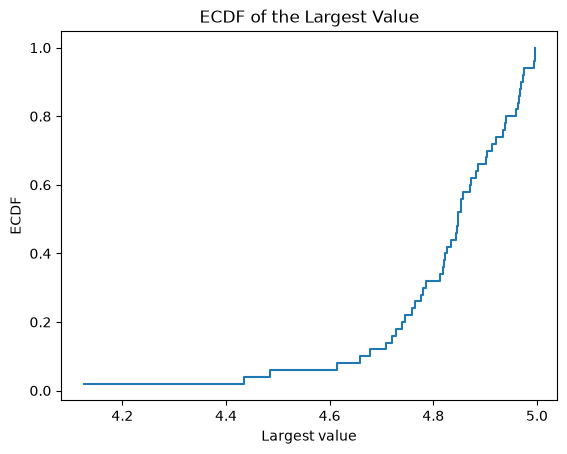

In [ ]:
rng = np.random.default_rng()

#1
k = 20
n = 50

unis = rng.uniform(1.0, 5.0, size=(n, k))

#2
unis_sorted = np.sort(unis, axis=1)

#3
largest = unis_sorted[:, -1]

#4
def ecdf(data):
    x = np.sort(data)
    y = np.arange(1, len(x) + 1) / len(x)
    return x, y


x, y = ecdf(largest)

plt.step(x, y, where='post')
plt.xlabel("Largest value")
plt.ylabel("ECDF")
plt.title("ECDF of the Largest Value")
plt.show()


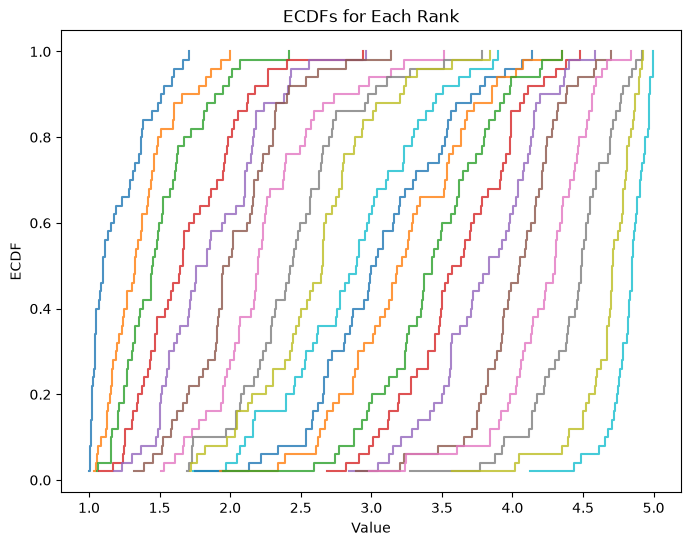

In [18]:
#5
fig, ax = plt.subplots(figsize=(8, 6))

for rank in range(1, k + 1):

    values = unis_sorted[:, rank - 1]

    x, y = ecdf(values)

    ax.step(x, y, where='post', alpha=0.8)

ax.set_xlabel("Value")
ax.set_ylabel("ECDF")
ax.set_title("ECDFs for Each Rank")
plt.show()

6)

Each individual point in each of the generated arrays follows a uniform distribution of U(0,5). However, each rank in the sorted arrays follows a beta distribution. This can change depending on rank, with k = 1 having a distribution of B(1,20) and k = 20 having a distribution of B(20,1). Additionally, rank changes the overall shape of the distribution, with small ranks concentrating near 0 and larger ranks concentrating near 1. 

# Q2)

In [22]:
#1

q2_unis = rng.uniform(-np.sqrt(3), np.sqrt(3), size = 32)

#2

mean_q2 = np.sqrt(32)*(q2_unis.mean())
mean_q2

np.float64(0.9834579079550885)

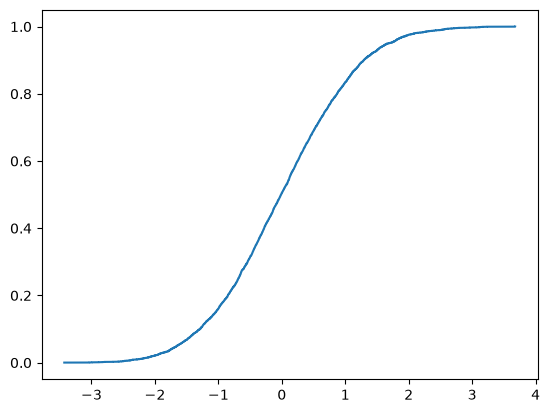

In [ ]:
#3

b = 5000
n_2 = 32

results = []

for i in range(b):
    data_2 = rng.uniform(-np.sqrt(3), np.sqrt(3), size = n_2)

    result = np.mean(data_2) * np.sqrt(n_2)
    results.append(result)
x2,y2 = ecdf(results)
plt.step(x2,y2, where = 'post')
plt.show()

4)

As n increases, the distribution that this approaches is the standard normal distribution. 

# Question 8)

In [32]:
import random
#1
n_8 = 1000
E = [1]*n_8

#2
i = random.randint(0,n_8 -1)
j = random.randint(0,n_8 - 1)

i_plus_j = E[i] + E[j]
#3
u_8 = rng.uniform(0,1)

E[i] = u_8 * i_plus_j
E[j] = (1-u_8)* i_plus_j


In [33]:
#4

b_8 = 1000000

for _ in range(b_8):
    i = rng.integers(0,n_8)
    j = rng.integers(0,n_8)

    i_plus_j = E[i] + E[j]
    u_8 = rng.uniform(0,1)

    E[i] = u_8 * i_plus_j
    E[j] = (1-u_8) * i_plus_j

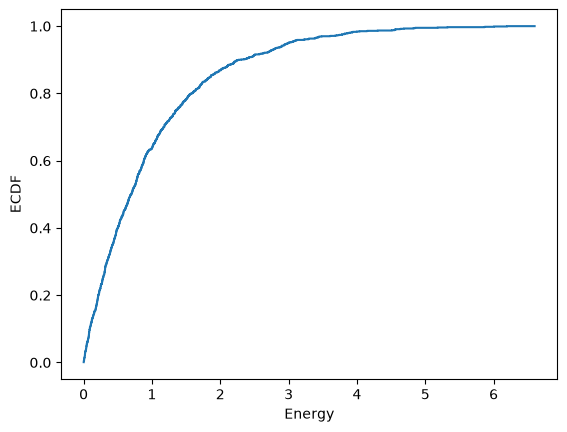

In [39]:
x = np.sort(E)
y = np.arange(1, n_8 + 1) / n_8

plt.step(x, y)
plt.xlabel("Energy")
plt.ylabel("ECDF")
plt.show()

The distribution approaches an exponential distribution as n grows large, with the ecdf being 1-e^-E. Changing the initial energy per particle changes the mean and scale of the exponential distribution, but the distirbution is still exponential. 

# Question 7)

Side note, Zipf's law applies to lots of things, including the lexica of languages. Across basically every human language, the most frequently used word is used at roughly double the frequency of the second most used word, three times as much as the third most used word and so on. 

In [38]:
#1

k_7 = 100000
cities = np.arange(1, k_7 + 1)
r = np.arange(1, k_7+1)

#2
s = 1
x = (k_7 / r) ** s

#3

n_7 = 5000
sampled_ranks = rng.choice(r, size = n_7)
sampled_sizes = (k_7 / sampled_ranks) ** s

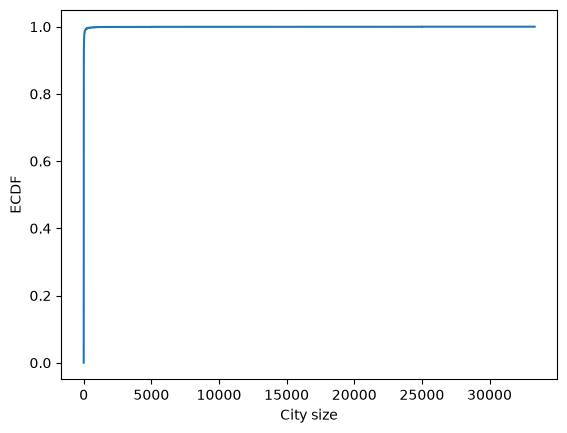

In [40]:
#4

x = np.sort(sampled_sizes)
y = np.arange(1, len(x) + 1) / len(x)
plt.step(x,y)
plt.xlabel('City size')
plt.ylabel('ECDF')
plt.show()


Zipf's law generates a pareto distribution, where P(X > x) ~ 1/x
With a larger s, sizes decrease more rapidly and the largest cities are far larger than the smaller ones. If s decreases, the small and large cities are closer together in size. 

